<a href="https://colab.research.google.com/github/chukaanyagu-afk/small_potato/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
url = "https://raw.githubusercontent.com/devzohaib/Simple-Linear-Regression/master/tvmarketing.csv"

In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/devzohaib/Simple-Linear-Regression/master/tvmarketing.csv")


In [ ]:
data.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [ ]:
# Extract the feature (TV) from the dataframe and reshape for scikit-learn
X = data.iloc[:, 0].values.reshape(-1, 1)
# Extract the target variable (Sales) from the dataframe
y = data.iloc[:, 1].values

In [ ]:
#import train_test splitfunction from sklearn's model-selection module
from sklearn.model_selection import train_test_split

In [ ]:
#split the data into training and testing sets
#test size is 30% converted to 0.3
#random state is for reproductability
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
#import the linear regression class from scikit-learns linear_modell module
from sklearn.linear_model import LinearRegression
#create an instance of LinearRegression class
lin_reg=LinearRegression()
#nearly all sklearn models use .fit function to train
lin_reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
#this gives us the train wweight coefficient and intercept
lin_reg.coef_


array([0.0464078])

In [ ]:
def viz_linear():
    plt.scatter(X_test,y_test,color='green')
    plt.plot(X_train,lin_reg.predict(X_train),color='blue')
    plt.title("Linear Regression model (Test set)")
    plt.xlabel("tv")
    plt.ylabel("sales")
    plt.show()

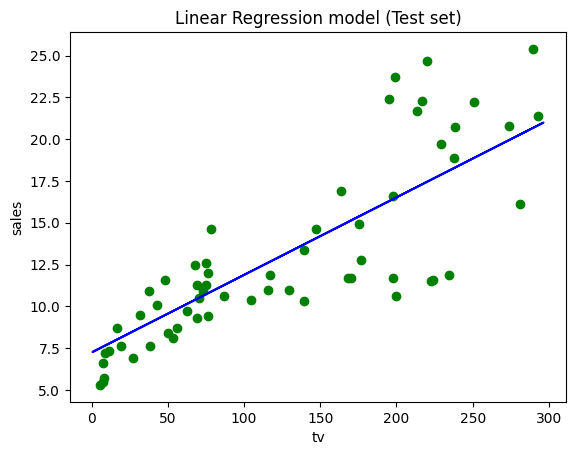

In [ ]:
viz_linear()

In [ ]:
test_predictions=lin_reg.predict(X_test)
print(test_predictions)

[14.81785392 16.30754437 20.83230507  7.78243112 17.46309864 10.72468577
 17.30067133  9.55984994 17.56055502 15.36546598  8.7013056   9.84757831
 18.12208943  7.49006196 13.71334823 15.13806775  7.57823679 16.40964153
 10.73396733 18.25667206 17.89005042 10.38590882  9.00295631 18.88317738
 10.44159818  9.72227724 17.14752559 13.70406667 11.28622018  7.62928537
 16.5117387  10.45087974 16.46997167  8.02375169 20.26612989 18.2937983
  9.48095667 19.94127527 12.67845424  8.51567439 12.62276488 15.45364081
  9.2396361  10.1306659  17.63480751  9.01223787 10.51585066 14.07532908
 12.09371593 10.78037513 10.86854996 15.05453371  7.64320771  7.60144069
 10.78501591 13.24462943 10.64579251 20.68380011  8.14905275 16.40964153]


In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
y_train_pred=lin_reg.predict(X_train)

In [ ]:
y_test_pred=lin_reg.predict(X_test)

In [ ]:
mse_train=mean_squared_error(y_train,y_train_pred)
mse_test=mean_squared_error(y_test,y_test_pred)
r2_train=r2_score(y_train,y_train_pred)
r2_test=r2_score(y_test,y_test_pred)

In [ ]:
print("training set mean squared error", mse_train)
print("testing set mean squared error", mse_test)
print("training set r2 score", r2_train)
print("testing set r2 score", r2_test)

training set mean squared error 11.189103289351676
testing set mean squared error 8.970991242413614
training set r2 score 0.5736021199591975
testing set r2 score 0.6714477229302764


In [ ]:
#testing all the cross validation


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold,LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
import io

csv_data = """longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
-118.30,33.81,34.0,1192.0,267.0,634.0,217.0,3.0250,212500.0,<1H OCEAN"""

housing_data = pd.read_csv(io.StringIO(csv_data))

In [ ]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-118.30,33.81,34.0,1192.0,267.0,634.0,217.0,3.0250,212500.0,<1H OCEAN


In [ ]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3 non-null      float64
 1   latitude            3 non-null      float64
 2   housing_median_age  3 non-null      float64
 3   total_rooms         3 non-null      float64
 4   total_bedrooms      3 non-null      float64
 5   population          3 non-null      float64
 6   households          3 non-null      float64
 7   median_income       3 non-null      float64
 8   median_house_value  3 non-null      float64
 9   ocean_proximity     3 non-null      object 
dtypes: float64(9), object(1)
memory usage: 372.0+ bytes


In [ ]:
housing_data['ocean_proximity'].value_counts()

,count
ocean_proximity,
NEAR BAY,2
<1H OCEAN,1


In [ ]:
housing_data.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
#assign values to X and y
X = housing_data.drop('median_house_value', axis=1)
y = housing_data['median_house_value']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)

#for hold out cross validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
kf=KFold(n_splits=2,shuffle=True,random_state=42)

In [ ]:
model=LinearRegression()

In [ ]:
k_fold_scores=cross_val_score(model,X_train,y_train,scoring='neg_mean_squared_error',cv=kf)

In [ ]:
k_fold_scores

array([-2.1316e+10, -2.1316e+10])

In [ ]:
import pandas as pd
import io
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Data loading and preprocessing for X_train, y_train (copied from prior cells for self-containment)
csv_data = """longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
-118.30,33.81,34.0,1192.0,267.0,634.0,217.0,3.0250,212500.0,<1H OCEAN
-118.35,33.78,20.0,1500.0,250.0,700.0,240.0,4.5000,180000.0,NEAR OCEAN
-122.00,38.00,30.0,2000.0,300.0,800.0,280.0,5.0000,250000.0,NEAR BAY
-117.90,34.05,25.0,1800.0,280.0,750.0,260.0,4.8000,220000.0,<1H OCEAN
-121.50,37.50,35.0,1000.0,150.0,400.0,140.0,3.5000,190000.0,INLAND"""
housing_data = pd.read_csv(io.StringIO(csv_data))

X = housing_data.drop('median_house_value', axis=1)
y = housing_data['median_house_value']
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model=LinearRegression()
#evaluate the model on the test set
model.fit(X_train,y_train)
y_test_pred=model.predict(X_test)
test_mse=mean_squared_error(y_test,y_test_pred)
test_r2=r2_score(y_test,y_test_pred)
print(f"test mse",test_mse)

#calculate R-squared score
test_r2=r2_score(y_test,y_test_pred)
print(f"test r2",test_r2)

test mse 107188707887.97845
test r2 -10.74458832502684


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Hitters.csv"

In [ ]:
df = pd.read_csv(url)


In [ ]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
df.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [ ]:
df.isnull().sum()

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


In [ ]:
dummies = pd.get_dummies(df[['League', 'Division', 'NewLeague']],dtype=int)
dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   League_A     322 non-null    int64
 1   League_N     322 non-null    int64
 2   Division_E   322 non-null    int64
 3   Division_W   322 non-null    int64
 4   NewLeague_A  322 non-null    int64
 5   NewLeague_N  322 non-null    int64
dtypes: int64(6)
memory usage: 15.2 KB


In [ ]:
dummies.head()

,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
0,1,0,1,0,1,0
1,0,1,0,1,0,1
2,1,0,0,1,1,0
3,0,1,1,0,0,1
4,0,1,1,0,0,1


In [ ]:
y=df['Salary']
x_numerical=df.drop(['Salary','League','Division','NewLeague'],axis=1).astype('float64')
list_numerical=x_numerical.columns
list_numerical

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors'],
      dtype='object')

In [ ]:
x=pd.concat([x_numerical,dummies],axis=1)
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        322 non-null    float64
 1   Hits         322 non-null    float64
 2   HmRun        322 non-null    float64
 3   Runs         322 non-null    float64
 4   RBI          322 non-null    float64
 5   Walks        322 non-null    float64
 6   Years        322 non-null    float64
 7   CAtBat       322 non-null    float64
 8   CHits        322 non-null    float64
 9   CHmRun       322 non-null    float64
 10  CRuns        322 non-null    float64
 11  CRBI         322 non-null    float64
 12  CWalks       322 non-null    float64
 13  PutOuts      322 non-null    float64
 14  Assists      322 non-null    float64
 15  Errors       322 non-null    float64
 16  League_A     322 non-null    int64  
 17  League_N     322 non-null    int64  
 18  Division_E   322 non-null    int64  
 19  Division

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler().fit(x_train[list_numerical])
x_train[list_numerical]=scalar.transform(x_train[list_numerical])
x_test[list_numerical]=scalar.transform(x_test[list_numerical])

In [ ]:
x_train.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,CWalks,PutOuts,Assists,Errors,League_A,League_N,Division_E,Division_W,NewLeague_A,NewLeague_N
168,-0.397522,-0.564851,-0.670974,-1.052955,-0.393382,-1.060741,-0.684910,-0.924502,-0.910332,-0.729716,...,-0.856822,-0.210356,-0.654364,-0.777869,1,0,0,1,1,0
148,0.780435,0.791703,-0.437296,0.306138,-0.355490,-0.584603,0.768478,0.560523,0.571824,-0.332183,...,-0.052093,0.071044,1.831723,0.315685,1,0,1,0,1,0
221,1.291745,1.459214,-0.320458,1.509906,0.061319,0.891425,-0.684910,-0.763020,-0.718487,-0.577718,...,-0.664141,0.147789,-0.676829,0.003241,0,1,1,0,0,1
227,1.265856,1.136225,0.847928,2.131206,0.061319,1.272336,-1.100164,-0.695302,-0.692186,-0.378952,...,-0.581023,0.147789,-0.669341,-0.777869,1,0,0,1,1,0
139,0.398569,0.081127,-1.021489,0.577957,-0.582840,1.558019,-1.100164,-0.928843,-0.918067,-0.776484,...,-0.694365,-0.031284,-0.714270,0.159463,1,0,0,1,0,1


In [ ]:
median_salary=y_train.median(skipna=True)
y_train=y_train.fillna(median_salary)
y_test=y_test.fillna(median_salary)

In [ ]:
lasso_model=Lasso(alpha=1,max_iter=10000).fit(x_train,y_train)
print("lasso coefficient",lasso_model.coef_)
print("lasso intercept",lasso_model.intercept_)

lasso coefficient [-3.10805286e+02  2.64550748e+02  2.41608506e+01  0.00000000e+00
 -0.00000000e+00  9.82750165e+01 -7.19293890e+01 -1.54880263e+02
  1.15476423e+02  0.00000000e+00  2.74324904e+02  2.22999446e+02
 -2.17312944e+02  5.04277317e+01  4.18395072e+01 -2.27688962e+01
 -2.38754040e+01  1.28003920e-14  1.18631076e+02 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00]
lasso intercept 457.38812457632446


In [ ]:
#training data
pred_train=lasso_model.predict(x_train)
mse_train=mean_squared_error(y_train,pred_train)
print('mse training set',round(mse_train,2))
print('R squared test set',round(r2_score(y_train,pred_train)*100,2))
print('------------------------')

mse training set 84531.03
R squared test set 47.15
------------------------


In [ ]:
#test data
pred_test=lasso_model.predict(x_test)
mse_test=mean_squared_error(y_test,pred_test)
print('mse test set',round(mse_test,2))
print('R squared test set',round(r2_score(y_test,pred_test),2))

mse test set 116175.54
R squared test set 0.38


In [ ]:
np.sqrt(mse_test)


np.float64(340.84532924835815)

In [ ]:
linear_reg=LinearRegression()
linear_reg.fit(x_train,y_train)
y_pred_train=linear_reg.predict(x_train)
lin_mse=mean_squared_error(y_train,y_pred_train)
lin_mse=np.sqrt(lin_mse)
print("linear regression mse on train set:",lin_mse)

linear regression mse on train set: 289.5596286703813


In [ ]:
from sklearn.linear_model import ElasticNetCV, ElasticNet

In [ ]:
elastic_net=ElasticNet(alpha=1.0,l1_ratio=0.5)
elastic_net.fit(x_train,y_train)
print(elastic_net.intercept_)
print(elastic_net.coef_)

504.5873302901059
[ -2.12212828  32.10657861   3.73958783  19.32062472  23.88774548
  23.60123788  -1.67651205  21.50982403  38.90248694  32.05015453
  34.63941798  41.53026526  -1.03758482  34.53368743   5.26936425
 -10.04871296  -8.75049311   8.75052835  33.25003563 -33.24999959
  -2.18858081   2.18857531]


In [ ]:
alphas=np.logspace(-2,2,100)
l1_ratios=np.linspace(0.01,1.0,100)
elastic_net_cv=ElasticNetCV(alphas=alphas,l1_ratio=l1_ratios,cv=5)
elastic_net_cv.fit(x_train,y_train)
print(elastic_net_cv.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3239.3368171732873, tolerance: 2948.5448396505876
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3651.842352744192, tolerance: 3078.2550293998283
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3150.4821641482413, tolerance: 2948.5448396505876
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergen

0.16297508346206444


In [ ]:
best_alpha=elastic_net_cv.alpha_
best_l1_ratio=elastic_net_cv.l1_ratio_
print("best alpha",best_alpha)
print("best l1_ratio",best_l1_ratio)

best alpha 0.16297508346206444
best l1_ratio 0.9500000000000001


In [ ]:
elastic_tuned=ElasticNet(alpha=best_alpha,l1_ratio=best_l1_ratio,max_iter=10000).fit(x_train,y_train)
print(elastic_tuned.intercept_)
print(elastic_tuned.coef_)
y_pred_tuned=elastic_tuned.predict(x_test)

504.8122061430081
[-269.44078467  218.06282648   16.26920393   15.7307204     5.67287996
   89.92043631  -78.58385442 -114.91208308  181.31935737   36.38343763
  185.493471    157.16583626 -193.51911272   51.05663924   42.10509226
  -28.04581897  -19.55005232   19.54829316   61.43772361  -61.4397222
    7.11029487   -7.11073438]


In [ ]:
mse=np.sqrt(mean_squared_error(y_test,y_pred_tuned))
print('root mean squared error:',mse)

root mean squared error: 339.9060119783554


In [ ]:
y_test.mean()

np.float64(549.2551481481481)

In [ ]:
coefficients=pd.Series(elastic_tuned.coef_,index=x_train.columns)
print(coefficients)

AtBat         -269.440785
Hits           218.062826
HmRun           16.269204
Runs            15.730720
RBI              5.672880
Walks           89.920436
Years          -78.583854
CAtBat        -114.912083
CHits          181.319357
CHmRun          36.383438
CRuns          185.493471
CRBI           157.165836
CWalks        -193.519113
PutOuts         51.056639
Assists         42.105092
Errors         -28.045819
League_A       -19.550052
League_N        19.548293
Division_E      61.437724
Division_W     -61.439722
NewLeague_A      7.110295
NewLeague_N     -7.110734
dtype: float64


In [ ]:
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.linear_model import Ridge

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
grid = {}
grid["alpha"] = np.arange(0,1,0.1)  # Using np.logspace for a better range for alpha

model = Ridge()
search = GridSearchCV(model, grid, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)
results = search.fit(x_train, y_train)
print(grid)
print("mae", results.best_score_)
print("config", results.best_params_)

{'alpha': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])}
mae -238.3988188631308
config {'alpha': np.float64(0.9)}
